## 1. Load and Inspect the Dataset

Load the raw Kaggle credit card fraud dataset and do a first visual check that it imported correctly — correct shape, correct column names, no parsing errors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/creditcard.csv')

print(df.shape)
df.head()

Matplotlib is building the font cache; this may take a moment.


(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,'0'
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,'0'
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,'0'
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,'0'
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,'0'


## 2. Class Imbalance

Quantify the core challenge of this project: how rare is fraud? Using a log-scale bar chart since the fraud class is otherwise invisible next to the legitimate class.

Class
'0'    284315
'1'       492
Name: count, dtype: int64
Class
'0'    99.827251
'1'     0.172749
Name: proportion, dtype: float64


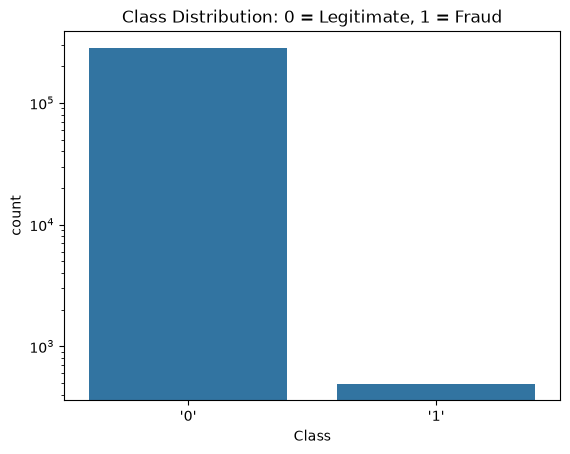

In [2]:
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print(class_counts)
print(class_pct)

sns.countplot(x='Class', data=df)
plt.title('Class Distribution: 0 = Legitimate, 1 = Fraud')
plt.yscale('log')
plt.show()

## 3. Data Quality Checks — Missing Values & Duplicates

Check for missing values and duplicate rows before doing any splitting or modeling. Duplicates are a known issue in this dataset and must be handled before train/test split to avoid data leakage.

In [3]:
print("Missing values:\n", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values:
 0
Duplicate rows: 1081


## 4. Remove Duplicate Rows

Drop the 1,081 exact duplicate rows identified above. This must happen before any train/test split to prevent the same transaction appearing in both sets.

In [4]:
print("Shape before:", df.shape)

df = df.drop_duplicates()

print("Shape after:", df.shape)
print("Duplicate rows remaining:", df.duplicated().sum())

Shape before: (284807, 31)
Shape after: (283726, 31)
Duplicate rows remaining: 0


In [5]:
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

Class
'0'    283253
'1'       473
Name: count, dtype: int64
Class
'0'    99.83329
'1'     0.16671
Name: proportion, dtype: float64


In [6]:
print("Shape after:", df.shape)
print(df['Class'].value_counts())

Shape after: (283726, 31)
Class
'0'    283253
'1'       473
Name: count, dtype: int64


## 5. Fix Class Column Data Type

The Class column was parsed as a quoted string ('0', '1') instead of an integer. Cast it to int — required for stratified splitting, scale_pos_weight, and SHAP later in the pipeline.

In [7]:
print(df['Class'].dtype)
print(df['Class'].unique())

df['Class'] = df['Class'].astype(str).str.strip("'").astype(int)

print(df['Class'].dtype)
print(df['Class'].unique())

str
<ArrowStringArray>
[''0'', ''1'']
Length: 2, dtype: str
int64
[0 1]


## 6. Distribution of `Amount` and `Time`

Examine the two interpretable raw features. `Amount` is expected to be heavily right-skewed; `Time` should show a bimodal daily pattern across the dataset's 2-day span.

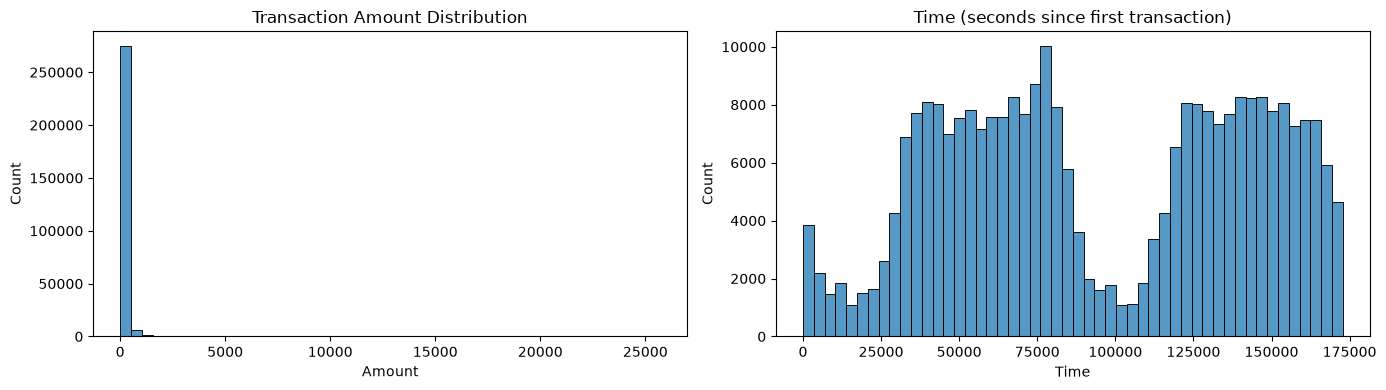

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['Amount'], bins=50, ax=axes[0])
axes[0].set_title('Transaction Amount Distribution')

sns.histplot(df['Time'], bins=50, ax=axes[1])
axes[1].set_title('Time (seconds since first transaction)')

plt.tight_layout()
plt.show()

## 7. Transaction Amount: Legitimate vs Fraud

Compare the `Amount` distribution between classes to check whether fraud transactions differ systematically in size from legitimate ones.

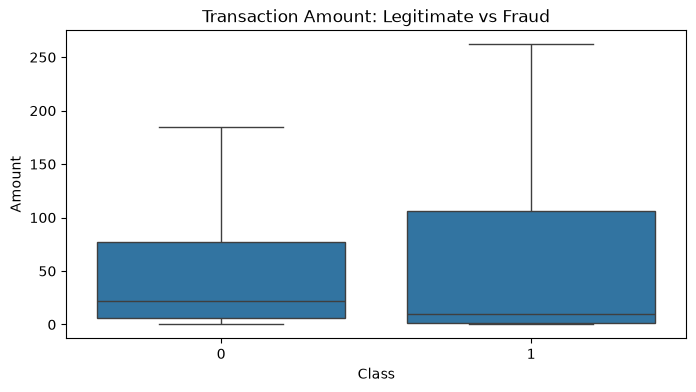

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      283253.0   88.413575  250.379023  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.871860  260.211041  0.0  1.00   9.82  105.89   2125.87


In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x='Class', y='Amount', data=df, showfliers=False)
plt.title('Transaction Amount: Legitimate vs Fraud')
plt.show()

print(df.groupby('Class')['Amount'].describe())

## 8. Linear Correlation with Fraud

Rank all features by Pearson correlation with `Class` as a fast first-pass signal check. Note: this only captures linear relationships — SHAP (Layer 3) will later capture non-linear and interaction effects this misses.

In [10]:
corr = df.corr()['Class'].sort_values(ascending=False)
print(corr)

Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
V22       0.004887
V26       0.004265
V25       0.003202
V15      -0.003300
V13      -0.003897
V23      -0.006333
V24      -0.007210
Time     -0.012359
V6       -0.043915
V5       -0.087812
V9       -0.094021
V1       -0.094486
V18      -0.105340
V7       -0.172347
V3       -0.182322
V16      -0.187186
V10      -0.206971
V12      -0.250711
V14      -0.293375
V17      -0.313498
Name: Class, dtype: float64


## 9. Correlation Heatmap — Top 10 Features

Visualize how the strongest features relate to `Class` and to each other, to spot redundancy among top predictors before modeling.

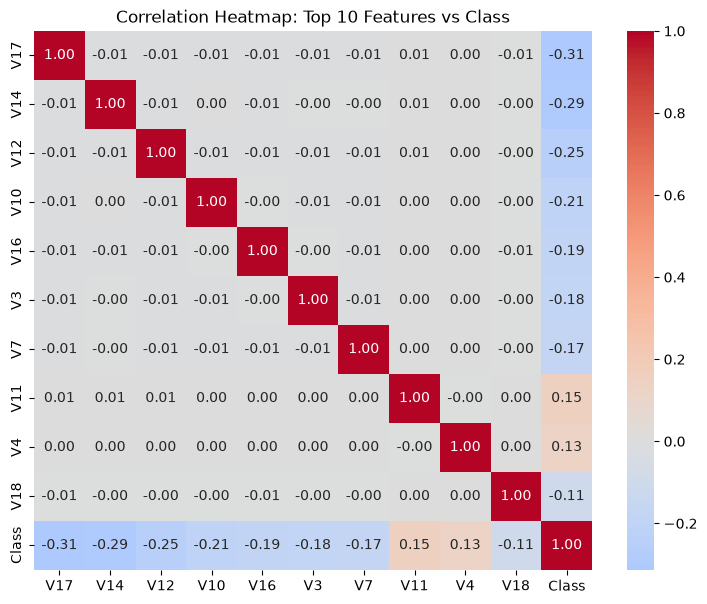

In [11]:
top_features = corr.abs().sort_values(ascending=False).index[1:11]  # exclude 'Class' itself
top_corr_matrix = df[list(top_features) + ['Class']].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(top_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: Top 10 Features vs Class')
plt.show()